# Do the Hello World example on 2-quibit Bell State

## Step 1: Map the problem to circuits and operations

In [1]:
from qiskit import QuantumCircuit
qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

# qc.draw(output='mpl')
print(qc.draw())


     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘


In [2]:
# Observables 

from qiskit.quantum_info import Pauli   
ZZ = Pauli('ZZ')
ZI = Pauli('ZI')
IZ = Pauli('IZ')
XX = Pauli('XX')
XI = Pauli('XI')
IX = Pauli('IX')

observables = [ZZ, ZI, IZ, XX, XI, IX]
# observables = [ZZ]
print(ZZ.to_matrix())

[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j -1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j  1.+0.j]]


## Step 2: Optimize

## Step 3: Execute on the backend

In [3]:
from qiskit_aer.primitives import Estimator

estimator = Estimator()
job = estimator.run([qc] * len(observables), observables)
job.result()


EstimatorResult(values=array([1.        , 0.02148438, 0.02148438, 1.        , 0.03320312,
       0.03320312]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 8, 'parallel_shots': 1, 'sample_measure_time': 0.0004715, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1], 'device': 'CPU', 'time_taken': 0.000950666, 'measure_sampling': True, 'num_clbits': 2, 'max_memory_mb': 16384, 'input_qubit_map': [[1, 1], [0, 0]], 'num_qubits': 2, 'method': 'stabilizer', 'required_memory_mb': 0, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9995384216308594, 'simulator_metadata': [{'num_bind_params': 1, 'runtime_parameter_bind': False, 'parallel_state_update': 8, 'parallel_shots': 1, 'sample_measure_time': 0.0004715, 'noise': 'ideal', 'batched_shots_optimization': False, 'remapped_qubits': False, 'active_input_qubits': [0, 1], 'de

## Step 4: Post Processing (and Plotting)

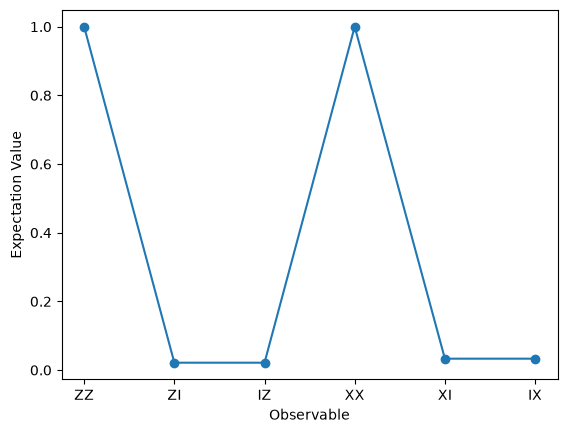

In [4]:
import matplotlib.pyplot as plt

data = ['ZZ', 'ZI', 'IZ', 'XX', 'XI', 'IX']
# data = ['ZZ']
values = job.result().values

plt.plot(data, values, '-o')
plt.xlabel('Observable')
plt.ylabel('Expectation Value')
plt.show()